In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# randoms_density = 2500.
# randoms = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/tmp/randoms_new_mask.fits'))

# # Apply the same mask bits and NOBS requirements as the LRG targets
# min_nobs = 1
# desi_maskbits = [1, 12, 13]
# mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
# print(np.sum(~mask)/len(randoms))
# randoms = randoms[mask]
# randoms_clean = np.ones(len(randoms), dtype=bool)
# for bit in desi_maskbits:
#     randoms_clean &= (randoms['MASKBITS'] & 2**bit)==0
# print(np.sum(~randoms_clean)/len(randoms))
# randoms = randoms[randoms_clean]
# print(len(randoms))

In [4]:
cat_stack = []

for field in ['south', 'north']:
    cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_{}_1.0.0_basic.fits'.format(field)))
    cat_wisemask = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_{}_1.0.0_wisemask.fits'.format(field)))
    cat_pz = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/targets/dr9.0/1.0.0/resolve/dr9_lrg_{}_1.0.0_pz_new.fits'.format(field)))
    wmask = np.load('/global/cfs/cdirs/desi/users/rongpu/desi_mask/dev/dr9_lrg_{}_1.0.0_basic-wisemask.npz'.format(field))
    gmask = np.load('/global/cfs/cdirs/desi/users/rongpu/desi_mask/dev/dr9_lrg_{}_1.0.0_basic-gaiamask.npz'.format(field))

    cat = hstack([cat, cat_wisemask, cat_pz], join_type='exact')
    cat['wise_mask'] = wmask['wise_mask']
    cat['gaia_mask'] = gmask['gaia_mask']
    cat['gaia_bright_mask'] = gmask['gaia_bright_mask']
    
    cat_stack.append(cat)
    
cat = vstack(cat_stack)
print(len(cat))

12338990


In [5]:
north = cat['PHOTSYS']=='N'
south = cat['PHOTSYS']=='S'

In [8]:
# DR9 mask

dr9_maskbits = [1, 8, 11, 12, 13]

dr9_mask = np.zeros(len(cat), dtype=bool)
for bit in dr9_maskbits:
    dr9_mask |= (cat['MASKBITS'] & 2**bit)>0
    
dr9_clean = ~dr9_mask
print(np.sum(dr9_clean)/len(dr9_clean))

0.8963934649432409


In [11]:
idx = np.where(~dr9_mask)[0]
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][idx], np.sin(np.radians(cat['DEC'][idx])), '.', ms=2, alpha=0.15)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_clean-dr9_mask.png')
plt.close()

idx = np.where(dr9_mask)[0]
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][idx], np.sin(np.radians(cat['DEC'][idx])), '.', ms=2, alpha=0.15)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_masked-dr9_mask.png')
plt.close()

In [6]:
# New mask

apply_unwise_spike = True
if apply_unwise_spike:
    wise_maskbits = [0, 1, 2, 3, 4, 6, 7]  # all except the HALO bit
else:
    wise_maskbits = [0, 2, 3, 4, 6, 7]  # all except the SPIKE and HALO bits

# Apply the unWISE maskbits
mask_unwise = np.zeros(len(cat), dtype=bool)
for bit in wise_maskbits:
    mask_unwise |= (cat['WISEMASK_W1'] & 2**bit)>0

wise_mask = cat['wise_mask'] | mask_unwise

new_mask = wise_mask | cat['gaia_mask']
mask_clean = ~(new_mask)

print(np.sum(mask_clean)/len(mask_clean))

0.8767090337215607


In [ ]:
idx = np.arange(len(cat))
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][idx], np.sin(np.radians(cat['DEC'][idx])), '.', ms=2, alpha=0.15)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_all.png')
plt.close()

idx = np.where(~new_mask)[0]
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][idx], np.sin(np.radians(cat['DEC'][idx])), '.', ms=2, alpha=0.15)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_clean.png')
plt.close()


idx = np.where(new_mask)[0]
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][idx], np.sin(np.radians(cat['DEC'][idx])), '.', ms=2, alpha=0.15)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_masked.png')
plt.close()

--------
## Photo-z outliers

In [7]:
min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(~mask)/len(mask))
cat = cat[mask]
new_mask = new_mask[mask]
mask_clean = mask_clean[mask]

mask = cat['Z_PHOT_MEDIAN']!=-99
print(np.sum(~mask)/len(mask))
cat = cat[mask]
new_mask = new_mask[mask]
mask_clean = mask_clean[mask]

0.0447497728744411
0.00010028147533902901


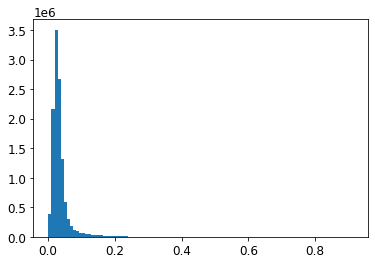

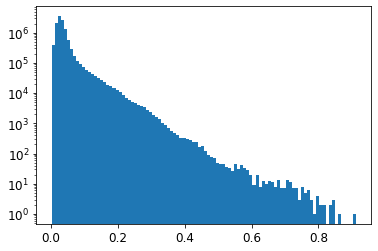

In [9]:
plt.hist(cat['Z_PHOT_STD']/(1+cat['Z_PHOT_MEDIAN']), 100)
plt.show()

plt.hist(cat['Z_PHOT_STD']/(1+cat['Z_PHOT_MEDIAN']), 100, log=True)
plt.show()

In [8]:
outliers = ((cat['Z_PHOT_STD']/(1+cat['Z_PHOT_MEDIAN']))>0.06)
print('All:   ', np.sum(outliers), np.sum(outliers)/len(cat)*100, '%')
print('Clean: ', np.sum(outliers & mask_clean), np.sum(outliers & mask_clean)/np.sum(mask_clean)*100, '%')
print('Masked:', np.sum(outliers & new_mask), np.sum(outliers & new_mask)/np.sum(new_mask)*100, '%')

All:    1024920 8.696344984545176 %
Clean:  564216 5.443592970496602 %
Masked: 460704 32.42410102549918 %


In [11]:
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][outliers], np.sin(np.radians(cat['DEC'][outliers])), '.', ms=2, alpha=1.)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_pz_outliers_all.png')
plt.close()

fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][outliers & mask_clean], np.sin(np.radians(cat['DEC'][outliers & mask_clean])), '.', ms=2, alpha=1)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_pz_outliers_clean.png')
plt.close()

In [17]:
outliers = ((cat['Z_PHOT_STD']/(1+cat['Z_PHOT_MEDIAN']))>0.12)
print('All:   ', np.sum(outliers), np.sum(outliers)/len(cat)*100, '%')
print('Clean: ', np.sum(outliers & mask_clean), np.sum(outliers & mask_clean)/np.sum(mask_clean)*100, '%')
print('Masked:', np.sum(outliers & new_mask), np.sum(outliers & new_mask)/np.sum(new_mask)*100, '%')

All:    298171 2.5299514892741093 %
Clean:  98319 0.9485881599711022 %
Masked: 199852 14.065476831432033 %


In [18]:
fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][outliers], np.sin(np.radians(cat['DEC'][outliers])), '.', ms=5, alpha=1.)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_pz_bad_outliers_all.png')
plt.close()

fig, ax = plt.subplots(figsize=(160, 60))
ax.plot(cat['RA'][outliers & mask_clean], np.sin(np.radians(cat['DEC'][outliers & mask_clean])), '.', ms=5, alpha=1)
ax.axis([360, 0, -0.95, 0.99])
ax.set_yticks(np.sin(np.radians(np.arange(-70, 90, 5))))
ax.set_yticklabels(np.arange(-70, 90, 5))
ax.set_xticks(np.arange(0, 360, 5))
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('/global/cfs/cdirs/desi/users/rongpu/imaging_sys/desi_mask/lrg/lrg_pz_bad_outliers_clean.png')
plt.close()

In [9]:
# idx = np.arange(len(cat))[::10]
# fig, ax = plt.subplots(figsize=(15, 10))
# ax.plot(cat['RA'][idx], np.sin(np.radians(cat['DEC'][idx])), '.', ms=1, alpha=0.1)
# ax.axis([360, 0, -0.95, 0.95])
# ax.set_yticks(np.sin(np.radians(np.arange(-70, 70, 5))))
# ax.set_yticklabels(np.arange(-70, 70, 5))
# ax.set_xticks(np.arange(0, 360, 5))
# ax.grid(alpha=0.5)
# plt.tight_layout()
# plt.show()